# CMSE 202 - Pneumonia Classification Using Traditional Machine Learning

## Perceptron Model

In [55]:
# Imports
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import load_files
from sklearn.decomposition import PCA
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from ipywidgets import interact

## Loading data and splitting the data

In [44]:
# Setup the directory paths
data_folder = os.path.join("..", "..", "data", "processed", "binary")
train_folder = os.path.join(data_folder, "train")
test_folder = os.path.join(data_folder, "test")
model_output_dir = os.path.join("..", "..", "models")

print(f"Train folder: {train_folder}")
print(f"Test folder: {test_folder}")

Train folder: ../../data/processed/binary/train
Test folder: ../../data/processed/binary/test


In [43]:
# Load in the images
train_dataset = load_files(train_folder, load_content=False)
test_dataset = load_files(test_folder, load_content=False)

X_train = [] 
X_test = []
y_train = train_dataset.target
y_test = test_dataset.target
categories = train_dataset.target_names

image_size = 128
grayscale = True

# Resize/grayscale the images and add them to respective arrays
for filename in train_dataset.filenames:
    try:
        img = Image.open(filename).convert("L" if grayscale else "RGB").resize((image_size, image_size))
        X_train.append(np.array(img).flatten())
    except Exception as e:
        print(f"Error loading image: {filename} - {e}")

for filename in test_dataset.filenames:
    try:
        img = Image.open(filename).convert("L" if grayscale else "RGB").resize((image_size, image_size))
        X_test.append(np.array(img).flatten())
    except Exception as e:
        print(f"Error loading image: {filename} - {e}")

X_train = np.array(X_train)
X_test = np.array(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (2000, 16384), Test shape: (500, 16384)


In [47]:
# View the train dataset
def browse_images(images, labels, filenames, categories):
    n = len(images)
    def view_image(i):
        plt.imshow(images[i], cmap=plt.cm.gray, interpolation='nearest')
        plt.title(f'{categories[labels[i]]} ({filenames[i].split('\\')[-1]})')
        plt.axis('off')
        plt.show()
    interact(view_image, i=(0,n-1))
    
browse_images(X_train.reshape([X_train.shape[0], image_size, image_size]), y_train, train_dataset.filenames, categories)

interactive(children=(IntSlider(value=999, description='i', max=1999), Output()), _dom_classes=('widget-intera…

In [51]:
# PCA to preserve 95% variance in the data
variance = 0.95
pca = PCA(n_components=variance)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"PCA reduced features from {X_train.shape[1]} to {X_train_pca.shape[1]} capturing {variance*100}% variance")

PCA reduced features from 16384 to 329 capturing 95.0% variance


## Creating Model

In [53]:
# Baseline Perceptron
param_grid = {
    'max_iter': [500, 1000],
    'eta0': [0.01, 0.1, 1.0],
    'penalty': ['l2', 'l1']
}

perc = Perceptron(random_state=42)
grid = GridSearchCV(perc, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train_pca, y_train)

print("Best Parameters:", grid.best_params_)

y_pred = grid.predict(X_test_pca)
print(classification_report(y_test, y_pred, target_names=categories))

Best Parameters: {'eta0': 0.01, 'max_iter': 500, 'penalty': 'l2'}
              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92       250
   Pneumonia       0.92      0.92      0.92       250

    accuracy                           0.92       500
   macro avg       0.92      0.92      0.92       500
weighted avg       0.92      0.92      0.92       500



## Creating confusion matrix

Text(0.5, 1.0, 'Confusion Matrix For Perceptron')

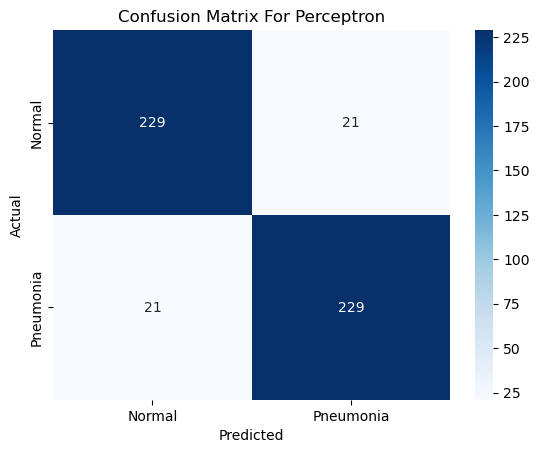

In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix For Perceptron")

In [35]:
# Save the model
model_file_path = os.path.join(model_output_dir, 'perceptron_model_base.pkl')
pickle.dump(grid.best_estimator_, open(model_file_path, 'wb'))